# 02 — Hubble-law fit using official Pantheon+SH0ES data

**Goal of this notebook:** build a Hubble diagram from the cleaned Pantheon+SH0ES data and estimate the slope of the local velocity-distance relation.

The simplified model is

$$
v = H_0 d,
$$

where `v` is approximated as $cz$. The important update in this notebook is that we do not hide the distance choice: Pantheon+ gives luminosity distance `D_L`, while a local linear Hubble-law plot is better represented by `D_L/(1+z)`. We compare both.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pantheon import (
    bootstrap_h0,
    distance_label,
    fit_h0_origin,
    fit_results_table,
    load_cleaned,
)
from src.plotting import plot_hubble_diagram, plot_mu_vs_redshift, plot_residuals


ModuleNotFoundError: No module named 'astropy'

## Load cleaned data

This notebook assumes that notebook 01 has already created:

```text
data/processed/pantheon_clean.csv
```

If the file was produced before the `hubble_distance_mpc` column existed, `load_cleaned` reconstructs it from `distance_mpc/(1+zHD)`.


In [ ]:
df = load_cleaned(PROJECT_ROOT / 'data/processed/pantheon_clean.csv')
print(df.shape)
df[['zHD', 'MU_SH0ES', 'distance_mpc', 'hubble_distance_mpc', 'velocity_km_s']].head()


(705, 24)


,zHD,MU_SH0ES,distance_mpc,hubble_distance_mpc,velocity_km_s
0,0.01016,32.7794,35.964995,35.603265,3045.891373
1,0.01017,32.9182,38.338931,37.952950,3048.889298
2,0.01017,32.9674,39.217509,38.822682,3048.889298
3,0.01026,33.3378,46.511463,46.039102,3075.870619
4,0.01026,33.2253,44.163146,43.714634,3075.870619


## Observational Hubble diagram

Astronomers often show supernova results as distance modulus versus redshift. Distance modulus is logarithmic, so this is not the same as a straight-line velocity-distance plot, but it is the natural observational view of the supernova data.


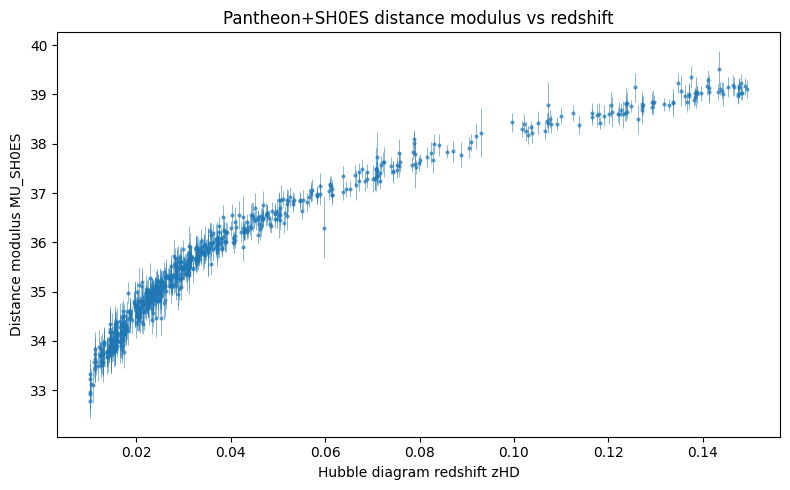

In [ ]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    df['zHD'],
    df['MU_SH0ES'],
    yerr=df['MU_SH0ES_ERR_DIAG'],
    fmt='.',
    alpha=0.6,
    markersize=4,
    linewidth=0.6,
)
plt.xlabel('Hubble diagram redshift zHD')
plt.ylabel('Distance modulus MU_SH0ES')
plt.title('Pantheon+SH0ES distance modulus vs redshift')
plt.tight_layout()
plt.show()


## Linearized Hubble-law form

The next plot uses the preferred local-distance proxy, `hubble_distance_mpc = D_L/(1+z)`. This is still a simplified low-redshift analysis, but it avoids the strongest avoidable bias from fitting `cz` directly against luminosity distance over the full `z <= 0.15` sample.


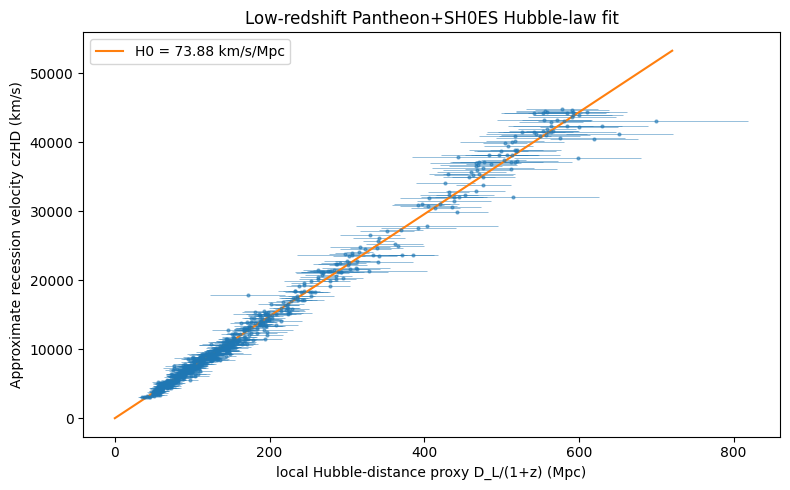

{'method': 'ordinary least squares, forced through origin',
 'distance_col': 'hubble_distance_mpc',
 'distance_definition': 'local Hubble-distance proxy D_L/(1+z)',
 'H0': 73.88008629421223,
 'intercept': 0.0,
 'rmse': 1105.2409978121127,
 'n': 705}

In [ ]:
main_distance = 'hubble_distance_mpc'
fit = fit_h0_origin(df, distance_col=main_distance)
h0 = fit['H0']

x = df[main_distance].to_numpy()
y = df['velocity_km_s'].to_numpy()
grid = np.linspace(0, x.max() * 1.03, 200)

plt.figure(figsize=(8, 5))
plt.errorbar(
    x,
    y,
    xerr=df['hubble_distance_err_mpc'],
    fmt='.',
    alpha=0.55,
    markersize=4,
    linewidth=0.6,
)
plt.plot(grid, h0 * grid, label=f'H0 = {h0:.2f} km/s/Mpc')
plt.xlabel(f'{distance_label(main_distance)} (Mpc)')
plt.ylabel('Approximate recession velocity czHD (km/s)')
plt.title('Low-redshift Pantheon+SH0ES Hubble-law fit')
plt.legend()
plt.tight_layout()
plt.show()
fit


## Distance-definition and method comparison

A line fit has choices. We compare two distance definitions and several fitting methods:

1. `distance_mpc`: the luminosity distance from the distance modulus.
2. `hubble_distance_mpc`: the local Hubble-distance proxy `D_L/(1+z)`.
3. Forced-origin ordinary least squares: the ideal Hubble law passes through zero.
4. Free-intercept ordinary least squares: useful as a diagnostic for offsets or model mismatch.
5. Huber robust regression: checks whether a few high-residual objects dominate.
6. Weighted fits: use the diagonal distance-modulus uncertainties as approximate relative weights.

These are sensitivity tests, not independent professional cosmology measurements.


In [ ]:
distance_cols = ['distance_mpc', 'hubble_distance_mpc']
fits = fit_results_table(df, distance_cols=distance_cols)
fits.to_csv(PROJECT_ROOT / 'report/pantheon_fit_results.csv', index=False)
fits[['distance_definition', 'method', 'H0', 'intercept', 'rmse', 'n']]


,distance_definition,method,H0,intercept,rmse,n
0,luminosity distance D_L,"ordinary least squares, forced through origin",67.015421,0.000000,1217.136262,705
1,luminosity distance D_L,"ordinary least squares, free intercept",64.525466,830.991789,1090.695379,705
2,luminosity distance D_L,Huber robust regression,65.646755,634.345214,1106.419497,705
3,luminosity distance D_L,"weighted least squares, forced through origin",67.453847,0.000000,1222.204195,705
4,luminosity distance D_L,"weighted least squares, free intercept",65.129555,833.777823,1101.699956,705
5,local Hubble-distance proxy D_L/(1+z),"ordinary least squares, forced through origin",73.880086,0.000000,1105.240998,705
6,local Hubble-distance proxy D_L/(1+z),"ordinary least squares, free intercept",73.944358,-18.948400,1105.177550,705
7,local Hubble-distance proxy D_L/(1+z),Huber robust regression,74.750534,-118.902125,1112.150152,705
8,local Hubble-distance proxy D_L/(1+z),"weighted least squares, forced through origin",74.573592,0.000000,1116.705666,705
9,local Hubble-distance proxy D_L/(1+z),"weighted least squares, free intercept",75.037530,-146.980470,1118.398379,705


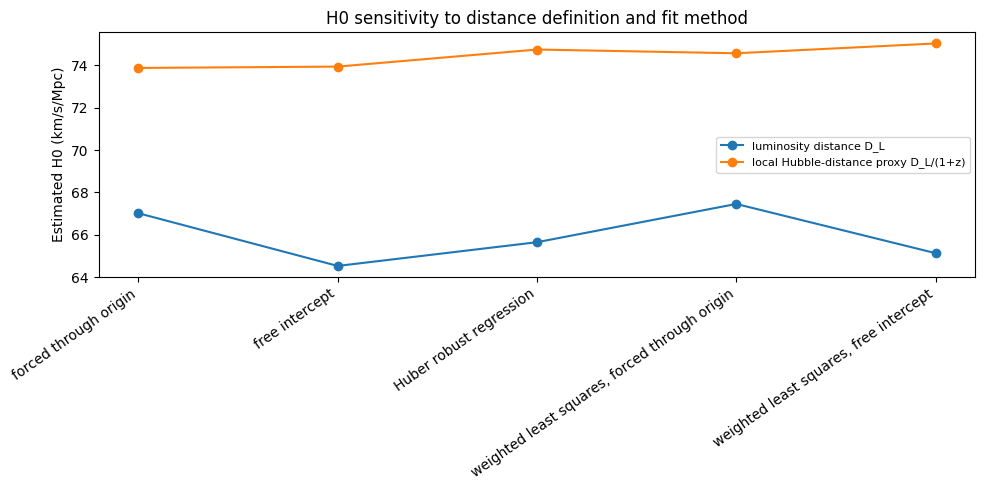

In [ ]:
plot_df = fits.copy()
plot_df['label'] = plot_df['method'].str.replace('ordinary least squares, ', '', regex=False)

plt.figure(figsize=(10, 5))
for distance_definition, sub in plot_df.groupby('distance_definition', sort=False):
    plt.plot(sub['label'], sub['H0'], marker='o', label=distance_definition)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Estimated H0 (km/s/Mpc)')
plt.title('H0 sensitivity to distance definition and fit method')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Residual analysis

Residuals show where the simple linear model fails. A random cloud around zero would mean the line captures the main trend. Structure in the residuals means the model is missing effects such as peculiar velocities, calibration scatter, or curvature beyond the local linear approximation.


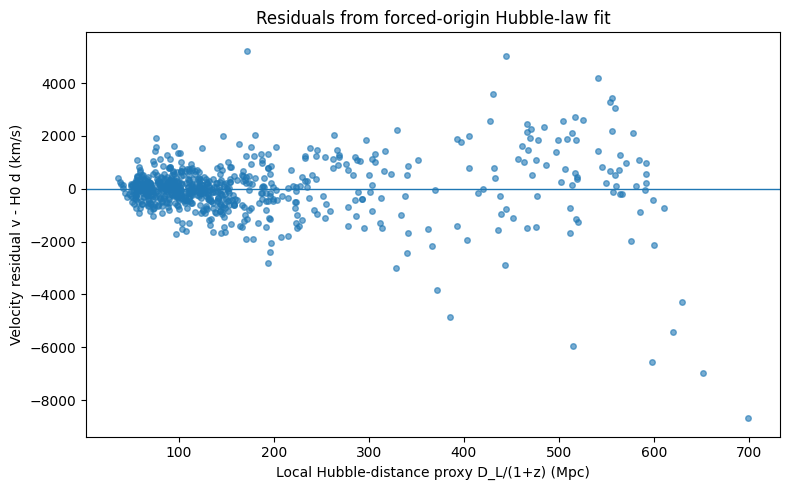

count     705.000000
mean       -7.401429
std      1106.000891
min     -8682.829882
25%      -409.867520
50%        -1.490343
75%       403.675214
max      5222.919068
dtype: float64

In [ ]:
h0 = fits.query("distance_col == 'hubble_distance_mpc' and method_key == 'origin'")['H0'].iloc[0]
residuals = df['velocity_km_s'] - h0 * df['hubble_distance_mpc']

plt.figure(figsize=(8, 5))
plt.scatter(df['hubble_distance_mpc'], residuals, s=16, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel('Local Hubble-distance proxy D_L/(1+z) (Mpc)')
plt.ylabel('Velocity residual v - H0 d (km/s)')
plt.title('Residuals from forced-origin Hubble-law fit')
plt.tight_layout()
plt.show()

pd.Series(residuals).describe()


## Bootstrap sampling uncertainty

The bootstrap resamples the supernova list with replacement and refits the slope. It does not include the full Pantheon+ covariance matrix, so it is not a final error bar, but it gives a useful class-project estimate of how much the fitted slope moves when the sample changes.


In [ ]:
bootstrap = pd.DataFrame([
    bootstrap_h0(df, method='origin', distance_col='hubble_distance_mpc', n_bootstrap=1000),
    bootstrap_h0(df, method='weighted_origin', distance_col='hubble_distance_mpc', n_bootstrap=1000),
])
bootstrap.to_csv(PROJECT_ROOT / 'report/pantheon_h0_bootstrap.csv', index=False)
bootstrap[['method', 'H0', 'H0_ci16', 'H0_ci84', 'H0_ci95_low', 'H0_ci95_high', 'n']]


,method,H0,H0_ci16,H0_ci84,H0_ci95_low,H0_ci95_high,n
0,"ordinary least squares, forced through origin",73.880086,73.515464,74.231354,73.17514,74.562430,705
1,"weighted least squares, forced through origin",74.573592,74.266255,74.849815,74.01067,75.086053,705


## Save figures

The same plots are saved for use in the report or presentation.


In [ ]:
plot_mu_vs_redshift(df, PROJECT_ROOT / 'figures/pantheon_mu_vs_redshift.png')
plot_hubble_diagram(df, PROJECT_ROOT / 'figures/pantheon_hubble_diagram.png', distance_col='hubble_distance_mpc')
plot_residuals(df, PROJECT_ROOT / 'figures/pantheon_residuals.png', distance_col='hubble_distance_mpc')
print('Saved figures to figures/.')


Saved figures to figures/.


## Hubble-fit conclusion

The cleaned Pantheon+SH0ES supernovae show the expected trend: more distant objects have larger redshift-derived recession velocities.

The most important comparison is that fitting `cz` against raw luminosity distance gives a lower and more redshift-dependent slope, while fitting against `D_L/(1+z)` gives a more stable local-Hubble estimate. The exact fitted value should still not be overinterpreted as a professional determination of $H_0$: this notebook uses a simplified velocity approximation and diagonal distance-modulus uncertainties.
